<a href="https://colab.research.google.com/github/81770977/Minor-Project-/blob/main/Minor_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Clustering System

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/smartcart_custers.csv/smartcart_customers.csv")
df.head()
df.shape

(2240, 22)

Data preprocessing

In [ ]:
df["Income"]=df["Income"].fillna(df["Income"].median())
df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


Feature Engineering

In [110]:
df["Age"]=2026-df["Year_Birth"]
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days
df.head()
df["Total_spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]
df["Total_children"]=df["Teenhome"]+df["Kidhome"]
df["Education"].value_counts()
df["Education"]=df["Education"].replace({
"Basic":"UG",
"2n Cycle":"UG",
"PhD":"PG",
"Master":"PG",
"Graduation":"G"
})
df["Education"].value_counts()

df["Living_With"]=df["Marital_Status"].replace({
    "YOLO":"alone",
    "Absurd":"alone",
    "Widow":"alone",
    "Married":"partner",
    "Together":"partner",
    "Single":"alone",
    "Divorced":"alone"
})
df["Living_With"].value_counts()

,count
Living_With,
partner,1444
alone,793
Alone,3


Drop Columns

In [111]:
Cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
Spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
Cols_to_drop=Cols + Spending_cols
df_Cleaned=df.drop(columns=Cols_to_drop,errors="ignore")
df_Cleaned.head()
print(df.columns)
print(df_Cleaned.columns)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_spending',
       'Total_children', 'Living_With'],
      dtype='object')
Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_spending', 'Total_children',
       'Living_With'],
      dtype='object')


OUTLIER

data size with outlier: 2240
data without outlier: 2212


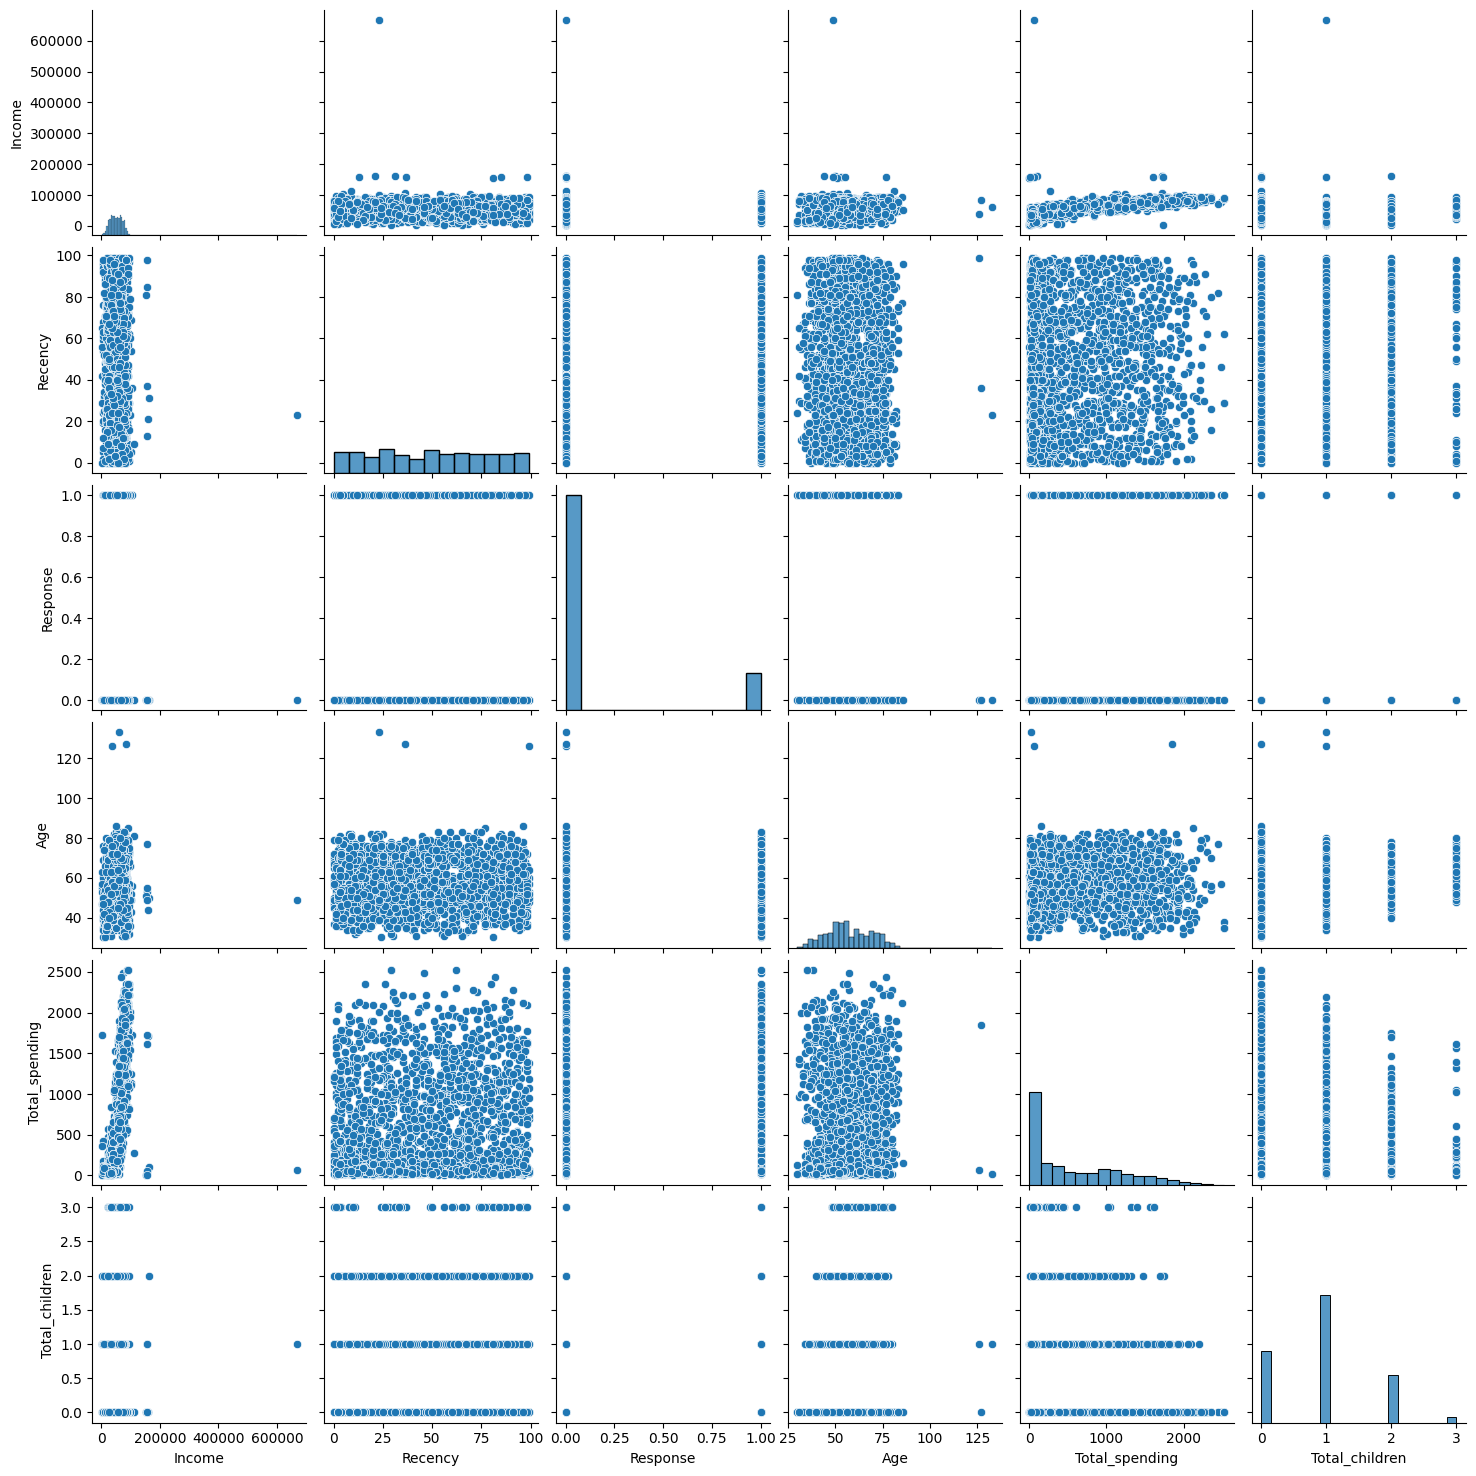

In [112]:
cols=["Income","Recency","Response","Age","Total_spending","Total_children"]
sns.pairplot(df_Cleaned[cols],diag_kind="hist")

#remove outliers
print("data size with outlier:",len(df_Cleaned))
df_Cleaned=df_Cleaned[(df_Cleaned["Age"]<90)]
df_Cleaned=df_Cleaned[(df_Cleaned["Income"]<600000)]
print("data without outlier:",len(df_Cleaned))

Heatmap

(2212, 15)

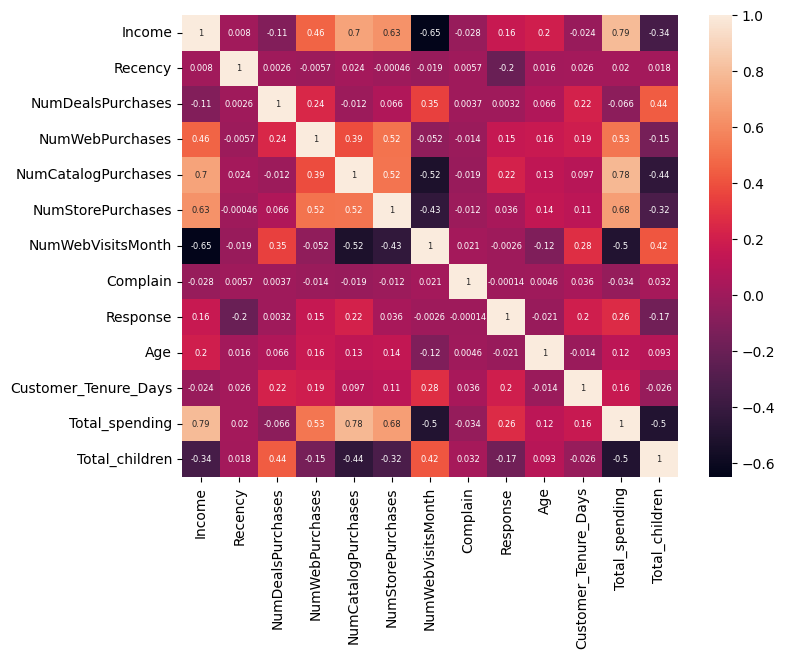

In [113]:
corr=df_Cleaned.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
corr,
annot=True,

annot_kws={"size":6}
)
df_Cleaned.shape

Encoding

In [114]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
cat_cols=["Education","Living_With"]
enc_cols=ohe.fit_transform(df_Cleaned[cat_cols])
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_Cleaned.index)
enc_df.head()
df_encoded=pd.concat([df_Cleaned.drop(columns=cat_cols),enc_df],axis=1)
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Education_G,Education_PG,Education_UG,Living_With_Alone,Living_With_alone,Living_With_partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,0.0,1.0


Scaling

In [115]:
from sklearn.preprocessing import StandardScaler
X=df_encoded
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled.shape

(2212, 19)

Visualize

In [116]:
from sklearn.decomposition import PCA
PCA=PCA(n_components=2)
x_pca=PCA.fit_transform(X_scaled)

PLOT #2d

array([0.22038224, 0.10777356])

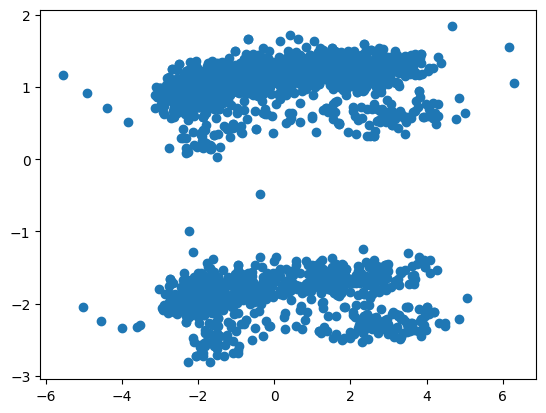

In [117]:
plt.scatter(x_pca[:,0],x_pca[:,1])
PCA.explained_variance_ratio_

3D plot

Text(0.5, 0.92, '3D')

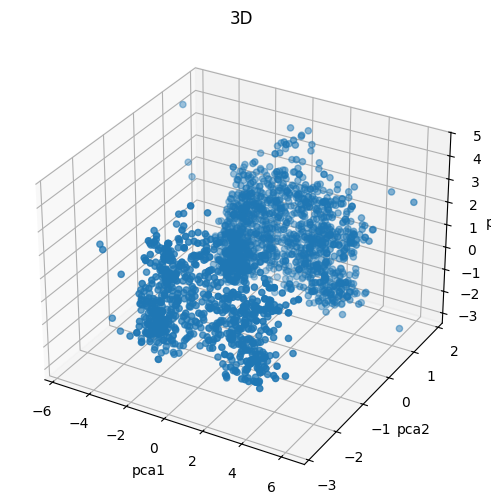

In [119]:
from sklearn.decomposition import PCA as PCATransformer
pca=PCATransformer(n_components=3)
x_pca=pca.fit_transform(X_scaled)
pca.explained_variance_ratio_
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3D")

Analyse K value

Text(0, 0.5, 'silhouette_score')

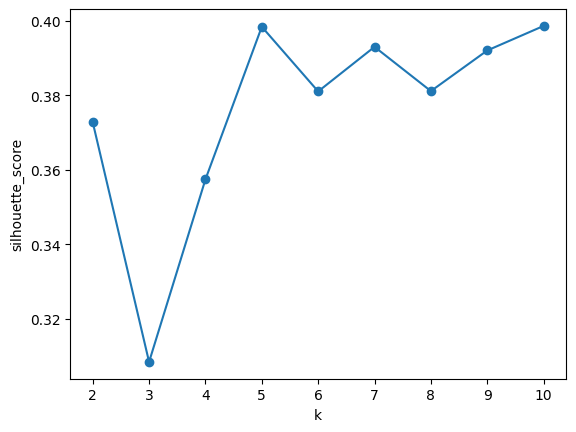

In [120]:

#silhouette score
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(x_pca)
    Score=silhouette_score(x_pca,labels)
    scores.append(Score)
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("k")
plt.ylabel("silhouette_score")

Clustering

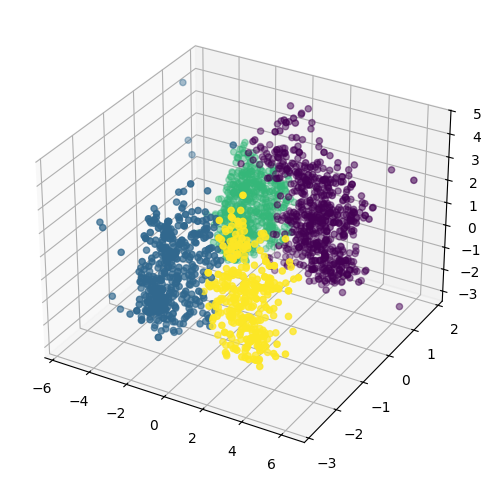

In [128]:
from sklearn.cluster import AgglomerativeClustering
agg_clg=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clg.fit_predict(x_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_agg)

Characteristics of clusters

<Axes: xlabel='cluster', ylabel='count'>

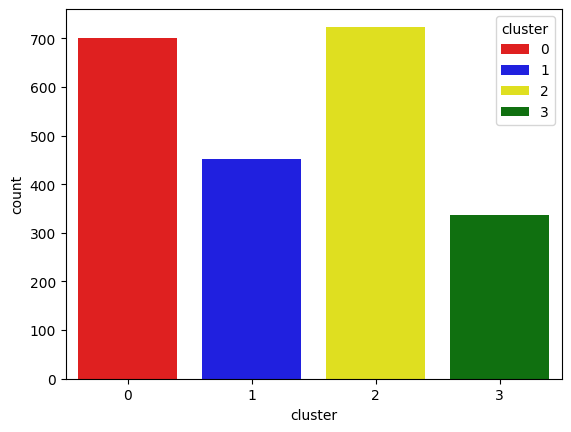

In [126]:

X["cluster"]=labels_agg
pal=["red","blue","yellow","green"]
sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])

income and spending patterns

<Axes: xlabel='Total_spending', ylabel='Income'>

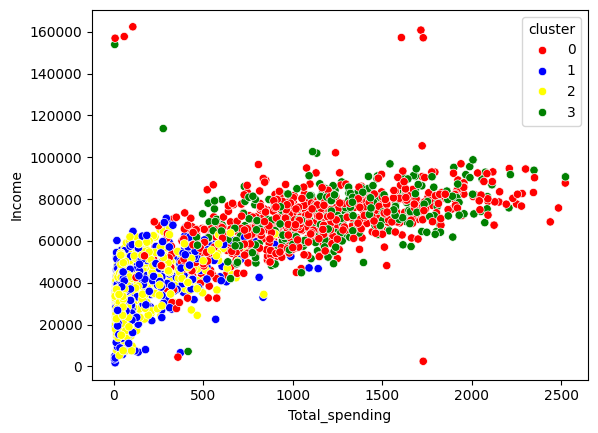

In [125]:
sns.scatterplot(x=X["Total_spending"],
y=X["Income"],hue=X["cluster"],
palette=pal)

Cluster summary

In [124]:
cluster_summary=X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        68558.203994  48.195435           2.456491         5.720399   
1        37276.294900  48.057650           2.605322         2.782705   
2        35928.167127  49.763812           2.255525         2.533149   
3        71577.339286  50.425595           1.821429         5.785714   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   4.707561           8.208274           4.074180  0.008559   
1                   0.909091           3.729490           6.616408  0.011086   
2                   0.665746           3.520718           6.480663  0.009669   
3                   5.116071           8.508929           3.687500  0.005952   

         Response        Age  Customer_Tenure_Days  Total_spending  \
cluster         